In [ ]:
pip install numpy pandas matplotlib scikit-learn yfinance schedule


In [ ]:
!pip install yfinance schedule pytz --quiet


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import schedule
import time
import pytz
from sklearn.ensemble import IsolationForest
from datetime import datetime
from IPython.display import clear_output
import requests


In [ ]:
TELEGRAM_BOT_TOKEN = 'your_new_token_here'  # 🔒 Replace with your secure bot token
TELEGRAM_CHAT_ID = 'your_chat_id_here'      # 🔍 Get it from @userinfobot

def send_telegram_alert(stock, price, timestamp):
    try:
        message = (
            f"🚨 Anomaly detected in {stock}\n"
            f"🕒 Time: {timestamp}\n"
            f"💰 Price: ₹{float(price):.2f}"
        )
        url = f"https://api.telegram.org/bot{TELEGRAM_BOT_TOKEN}/sendMessage"
        payload = {
            "chat_id": TELEGRAM_CHAT_ID,
            "text": message
        }
        response = requests.post(url, data=payload)
        if response.status_code != 200:
            print(f"⚠️ Telegram error: {response.text}")
    except Exception as e:
        print(f"⚠️ Failed to send Telegram alert: {e}")


In [ ]:
def fetch_stock_data(stock_symbol='RELIANCE.NS', interval='1m', period='1d'):
    df = yf.download(tickers=stock_symbol, period=period, interval=interval, progress=False)
    df = df.reset_index()
    df.rename(columns={'Datetime': 'Date'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    ist = pytz.timezone('Asia/Kolkata')
    if df['Date'].dt.tz is None:
        df['Date'] = df['Date'].dt.tz_localize('UTC').dt.tz_convert(ist)
    else:
        df['Date'] = df['Date'].dt.tz_convert(ist)

    return df


In [ ]:
class AdaptiveIsolationForest:
    def __init__(self, base_contamination=0.05):
        self.base_contamination = base_contamination
        self.model = None

    def fit(self, X, volatility):
        contamination_rate = min(0.1, self.base_contamination * (1 + volatility.mean()))
        self.model = IsolationForest(contamination=contamination_rate, random_state=42)
        self.model.fit(X)

    def predict(self, X):
        return self.model.predict(X)


In [ ]:
def detect_anomalies(df):
    if 'Close' not in df.columns or df.empty:
        print("❌ Error: 'Close' column missing or empty data.")
        return df

    df['Volatility'] = df['Close'].pct_change().rolling(window=min(10, len(df))).std()

    if df['Volatility'].isnull().all():
        print("⚠️ Not enough data to compute volatility.")
        return df

    aif = AdaptiveIsolationForest()
    aif.fit(df[['Close']], df['Volatility'])
    df['Anomaly'] = aif.predict(df[['Close']])
    print("✅ Anomaly column added.")
    return df


In [ ]:
def plot_anomalies(df, stock):
    clear_output(wait=True)
    plt.figure(figsize=(14, 6))
    plt.plot(df['Date'], df['Close'], label='Close Price', color='blue')

    if 'Anomaly' in df.columns:
        anomalies = df[df['Anomaly'] == -1]
        plt.scatter(anomalies['Date'], anomalies['Close'], color='red', label='Anomalies', marker='x')

    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.title(f'Real-Time Anomaly Detection for {stock}')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
def run_realtime(stock='RELIANCE.NS', cycles=3):
    print(f"📈 Monitoring {stock}...")
    for _ in range(cycles):
        try:
            df = fetch_stock_data(stock_symbol=stock)
            df = detect_anomalies(df)
            if df is not None:
                plot_anomalies(df, stock)
                df.to_csv(f'{stock.replace(".NS", "")}_anomaly_log.csv', index=False)

                # ✅ Send alert if latest point is an anomaly
                if df['Anomaly'].iloc[-1] == -1:
                    price = df['Close'].iloc[-1]
                    timestamp = df['Date'].iloc[-1]
                    send_telegram_alert(stock, price, timestamp)

            time.sleep(60)  # 1-minute interval
        except Exception as e:
            print(f"⚠️ Error in {stock}: {e}")
            time.sleep(60)


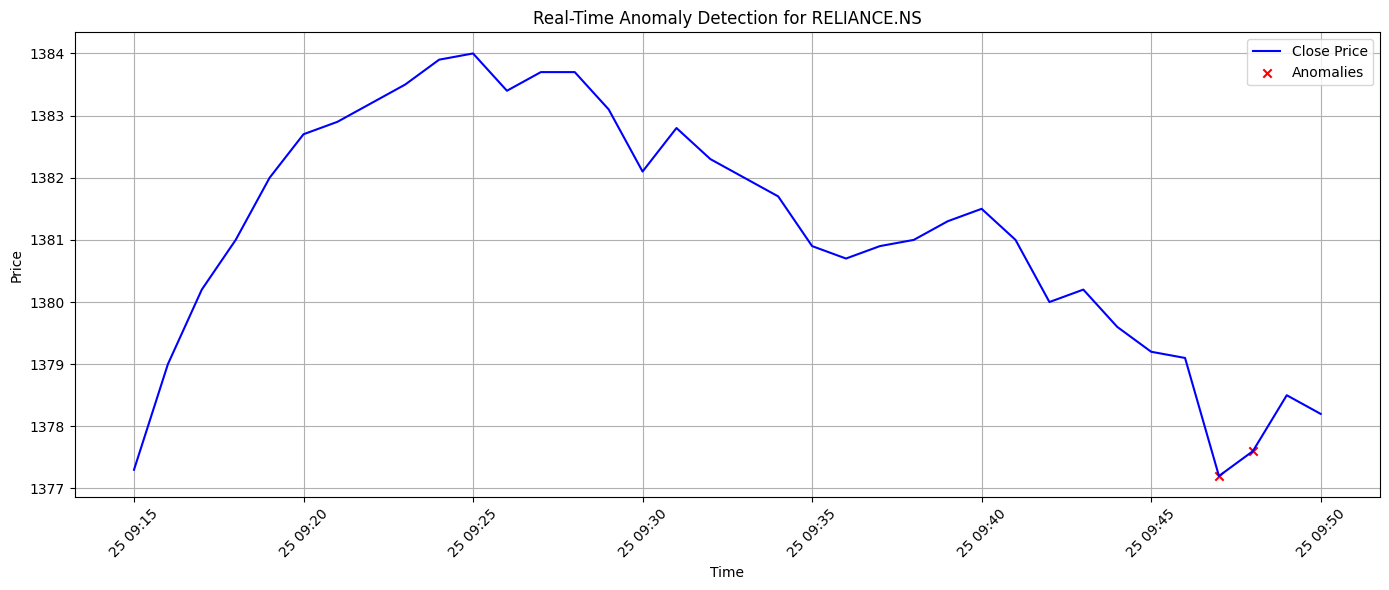

In [ ]:
# ✅ Change stock symbol or add more
run_realtime('RELIANCE.NS', cycles=3)


/tmp/ipython-input-372220490.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers=stock_symbol, period=period, interval=interval, progress=False)
/tmp/ipython-input-372220490.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Volatility'].fillna(method='bfill', inplace=True)
/tmp/ipython-input-372220490.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Volatility'].fillna(method='bfill', inplace=True)


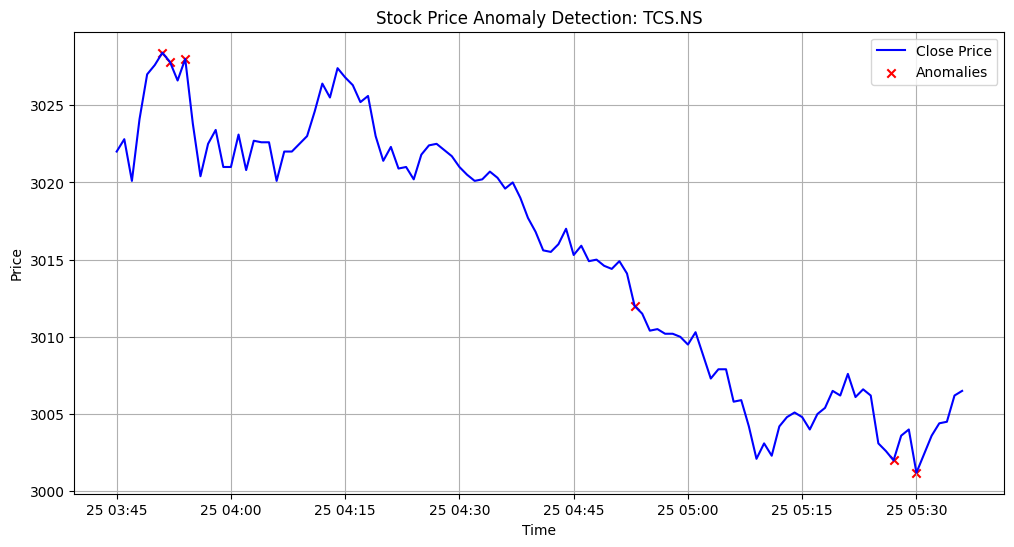

✅ Results saved to TCS.NS_anomalies.csv


In [ ]:
# ==================== Install Required Libraries ====================
!pip install yfinance matplotlib scikit-learn --quiet

# ==================== Import Modules ====================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# ==================== 1️⃣ Fetch Live Stock Data ====================
def fetch_stock_data(stock_symbol='TCS.NS', interval='1m', period='1d'):
    """
    Fetch stock data from Yahoo Finance.
    """
    df = yf.download(tickers=stock_symbol, period=period, interval=interval, progress=False)
    df = df.reset_index()
    df.rename(columns={'Datetime':'Date'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    return df

# ==================== 2️⃣ Compute Volatility ====================
def compute_volatility(df):
    df['Volatility'] = df['Close'].pct_change().rolling(min(10, len(df))).std()
    df['Volatility'].fillna(method='bfill', inplace=True)
    return df

# ==================== 3️⃣ Adaptive Isolation Forest ====================
def detect_anomalies(df):
    contamination_rate = min(0.1, 0.05 * (1 + df['Volatility'].mean()))
    model = IsolationForest(contamination=contamination_rate, random_state=42)
    df['Anomaly'] = model.fit_predict(df[['Close']])
    return df

# ==================== 4️⃣ Plot Anomalies ====================
def plot_anomalies(df, stock_symbol):
    plt.figure(figsize=(12,6))
    plt.plot(df['Date'], df['Close'], label='Close Price', color='blue')
    plt.scatter(df[df['Anomaly']==-1]['Date'], df[df['Anomaly']==-1]['Close'],
                color='red', label='Anomalies', marker='x')
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.title(f'Stock Price Anomaly Detection: {stock_symbol}')
    plt.legend()
    plt.grid(True)
    plt.show()

# ==================== 5️⃣ Run the Pipeline ====================
def run_stock_anomaly(stock_symbol='TCS.NS'):
    df = fetch_stock_data(stock_symbol)
    if df.empty:
        print("❌ No data fetched. Check stock symbol.")
        return
    df = compute_volatility(df)
    df = detect_anomalies(df)
    plot_anomalies(df, stock_symbol)
    # Save to CSV
    df.to_csv(f'{stock_symbol}_anomalies.csv', index=False)
    print(f"✅ Results saved to {stock_symbol}_anomalies.csv")

# ==================== 6️⃣ Example Run ====================
run_stock_anomaly('TCS.NS')  # Change symbol to 'INFY.NS', 'RELIANCE.NS', etc.


In [ ]:
# ==================== Install Libraries ====================
!pip install yfinance matplotlib scikit-learn --quiet

# ==================== Import Modules ====================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import os
import warnings

# ==================== Suppress Warnings ====================
warnings.filterwarnings("ignore")

# ==================== Create Folder to Save Plots ====================
os.makedirs("stock_analysis", exist_ok=True)

# ==================== Fetch Stock Data ====================
def fetch_stock_data(stock_symbol='TCS.NS', interval='1m', period='1d'):
    df = yf.download(
        tickers=stock_symbol,
        period=period,
        interval=interval,
        progress=False,
        auto_adjust=False  # Fix future warning
    )
    df = df.reset_index()
    df.rename(columns={'Datetime':'Date'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    return df

# ==================== Compute Volatility ====================
def compute_volatility(df):
    df['Volatility'] = df['Close'].pct_change().rolling(min(10,len(df))).std()
    df['Volatility'] = df['Volatility'].bfill()  # Fix warnings
    return df

# ==================== Detect Anomalies ====================
def detect_anomalies(df):
    contamination_rate = min(0.1, 0.05 * (1 + df['Volatility'].mean()))
    model = IsolationForest(contamination=contamination_rate, random_state=42)
    df['Anomaly'] = model.fit_predict(df[['Close']])
    return df

# ==================== Plot Diagrams ====================
def plot_diagrams(df, stock_symbol):
    folder = "stock_analysis"

    # 1️⃣ Stock Price vs Time
    plt.figure(figsize=(18,9))
    plt.plot(df['Date'], df['Close'], color='blue')
    plt.xlabel('Time')
    plt.ylabel('Close Price')
    plt.title(f'{stock_symbol} Stock Price Over Time')
    plt.grid(True)
    plt.savefig(f'{folder}/{stock_symbol}_price_plot.png', dpi=300)
    plt.close()

    # 2️⃣ Anomalies
    plt.figure(figsize=(18,9))
    plt.plot(df['Date'], df['Close'], label='Close Price', color='blue')
    anomalies = df[df['Anomaly']==-1]
    plt.scatter(anomalies['Date'], anomalies['Close'], color='red', label='Anomalies', marker='x')
    plt.xlabel('Time')
    plt.ylabel('Close Price')
    plt.title(f'{stock_symbol} Stock Price Anomalies')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'{folder}/{stock_symbol}_anomalies_plot.png', dpi=300)
    plt.close()

    # 3️⃣ Volatility
    plt.figure(figsize=(18,9))
    plt.plot(df['Date'], df['Volatility'], color='green')
    plt.xlabel('Time')
    plt.ylabel('Volatility')
    plt.title(f'{stock_symbol} Stock Price Volatility')
    plt.grid(True)
    plt.savefig(f'{folder}/{stock_symbol}_volatility_plot.png', dpi=300)
    plt.close()

# ==================== Run Pipeline for Multiple Stocks ====================
def run_multiple_stocks(stock_list):
    for stock in stock_list:
        print(f"🔁 Processing {stock} ...")
        df = fetch_stock_data(stock)
        if df.empty:
            print(f"❌ No data for {stock}. Skipping.")
            continue
        df = compute_volatility(df)
        df = detect_anomalies(df)
        plot_diagrams(df, stock)
        df.to_csv(f'stock_analysis/{stock}_analysis.csv', index=False)
        print(f"✅ Finished {stock}. Plots & CSV saved.")

# ==================== Example Run ====================
indian_stocks = ['TCS.NS', 'INFY.NS', 'RELIANCE.NS', 'HCLTECH.NS', 'WIPRO.NS']
run_multiple_stocks(indian_stocks)


🔁 Processing TCS.NS ...
✅ Finished TCS.NS. Plots & CSV saved.
🔁 Processing INFY.NS ...
✅ Finished INFY.NS. Plots & CSV saved.
🔁 Processing RELIANCE.NS ...
✅ Finished RELIANCE.NS. Plots & CSV saved.
🔁 Processing HCLTECH.NS ...
✅ Finished HCLTECH.NS. Plots & CSV saved.
🔁 Processing WIPRO.NS ...
✅ Finished WIPRO.NS. Plots & CSV saved.


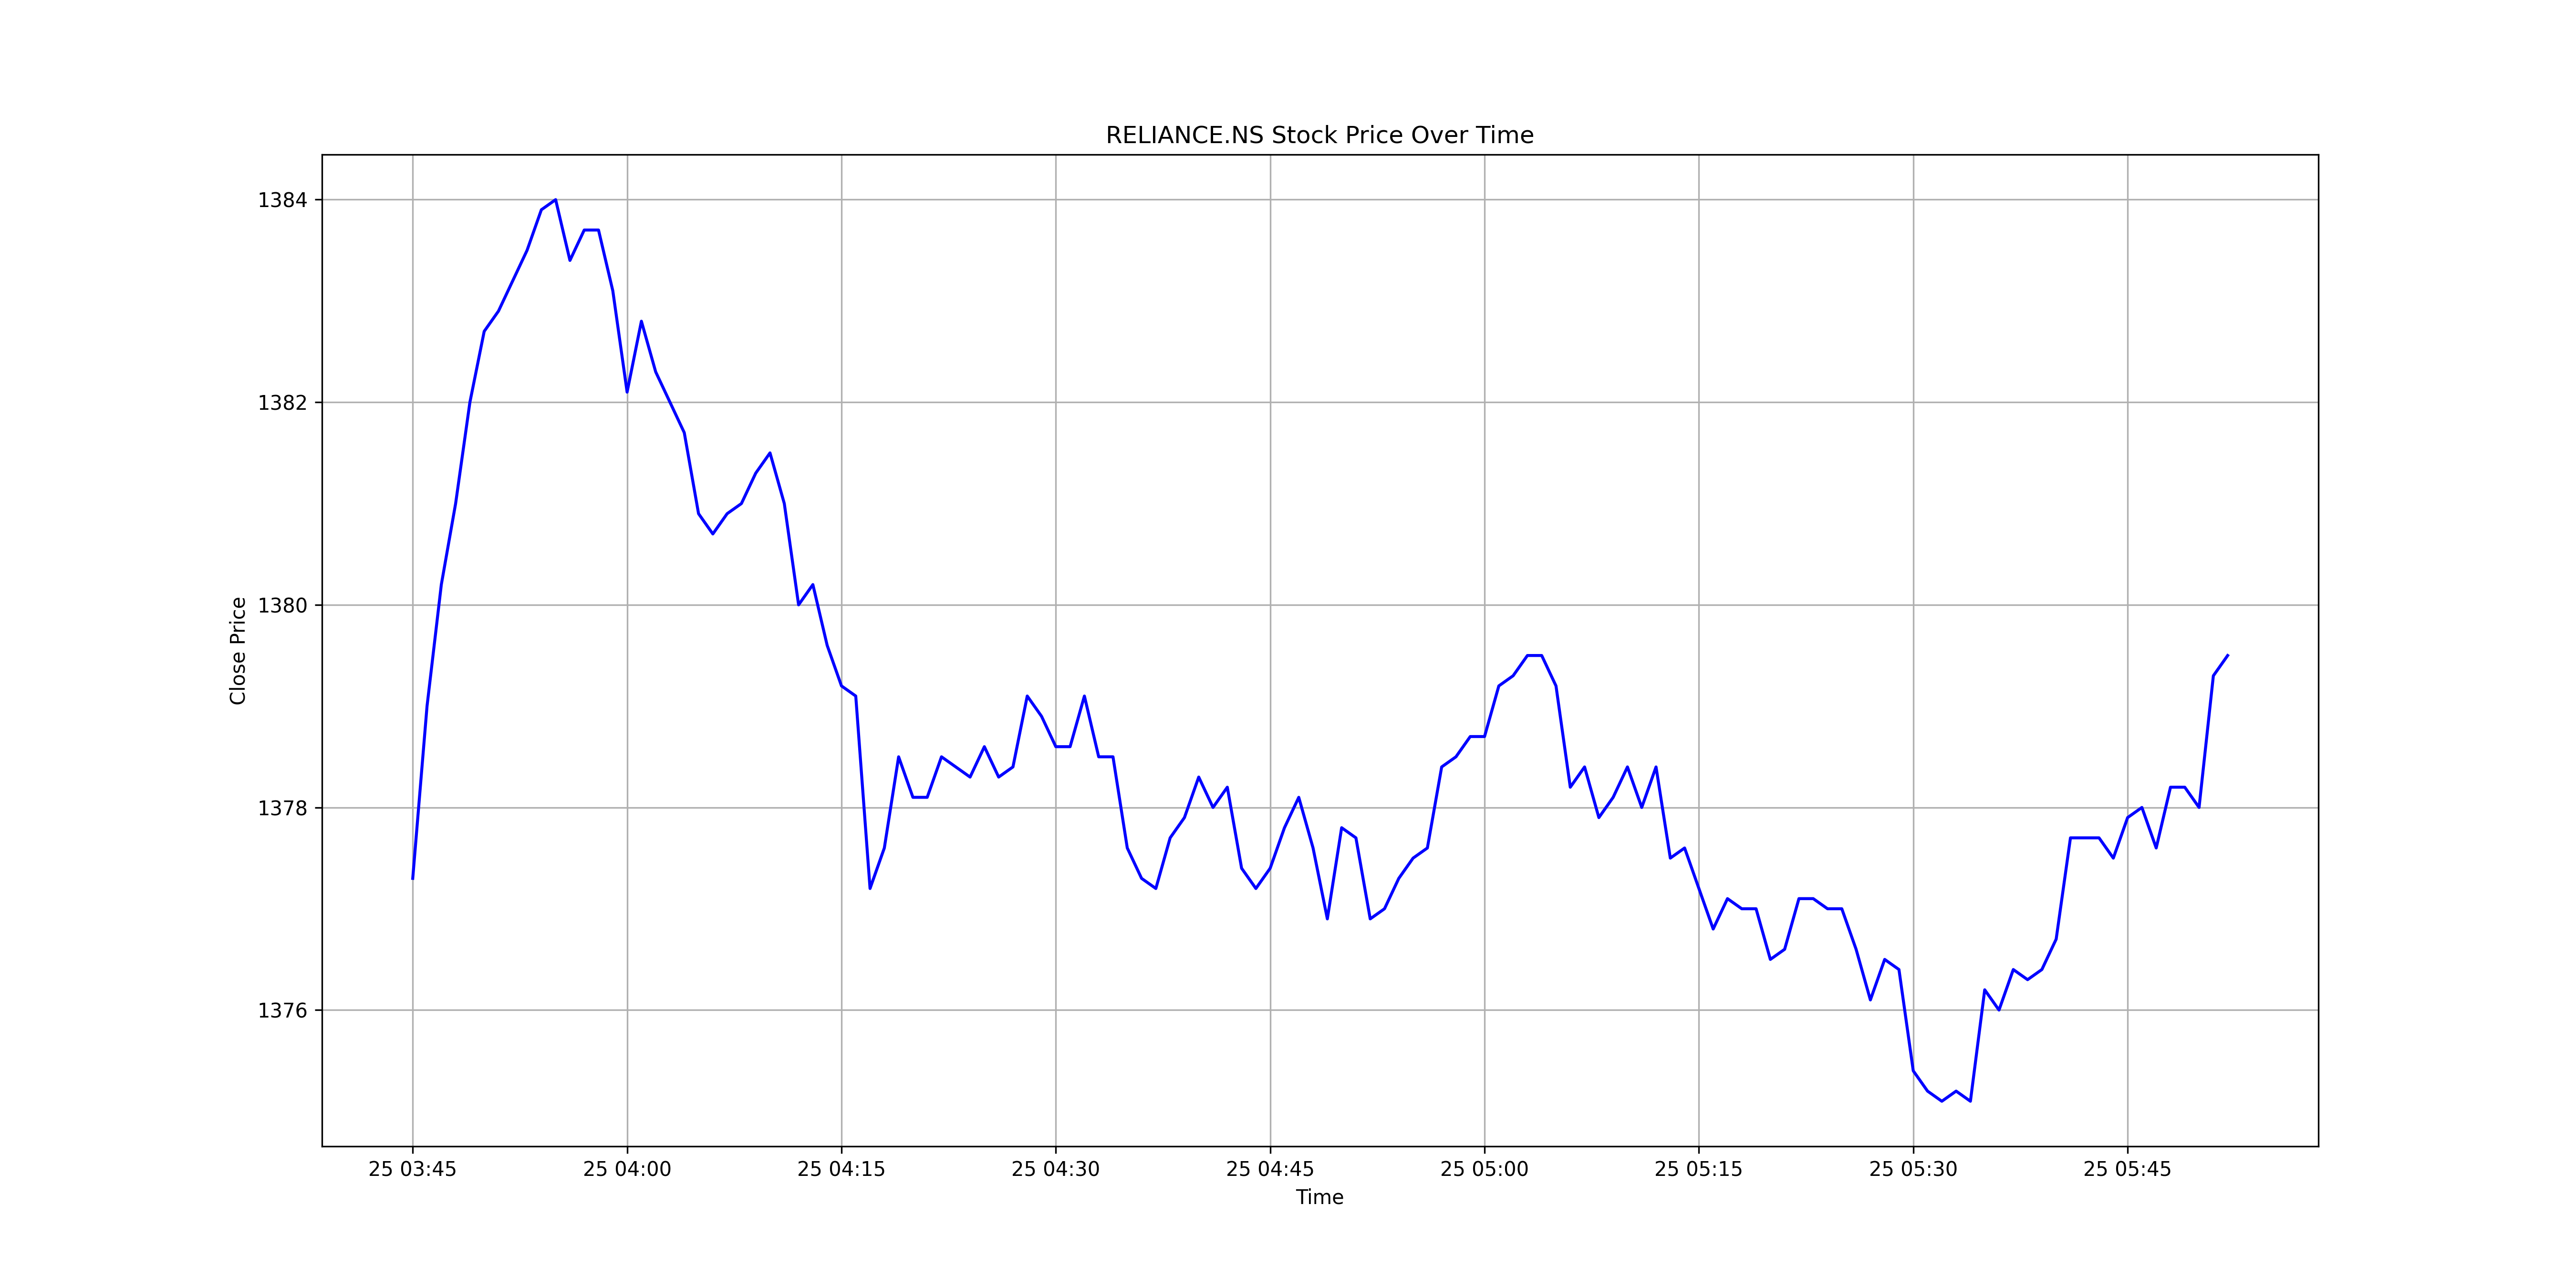

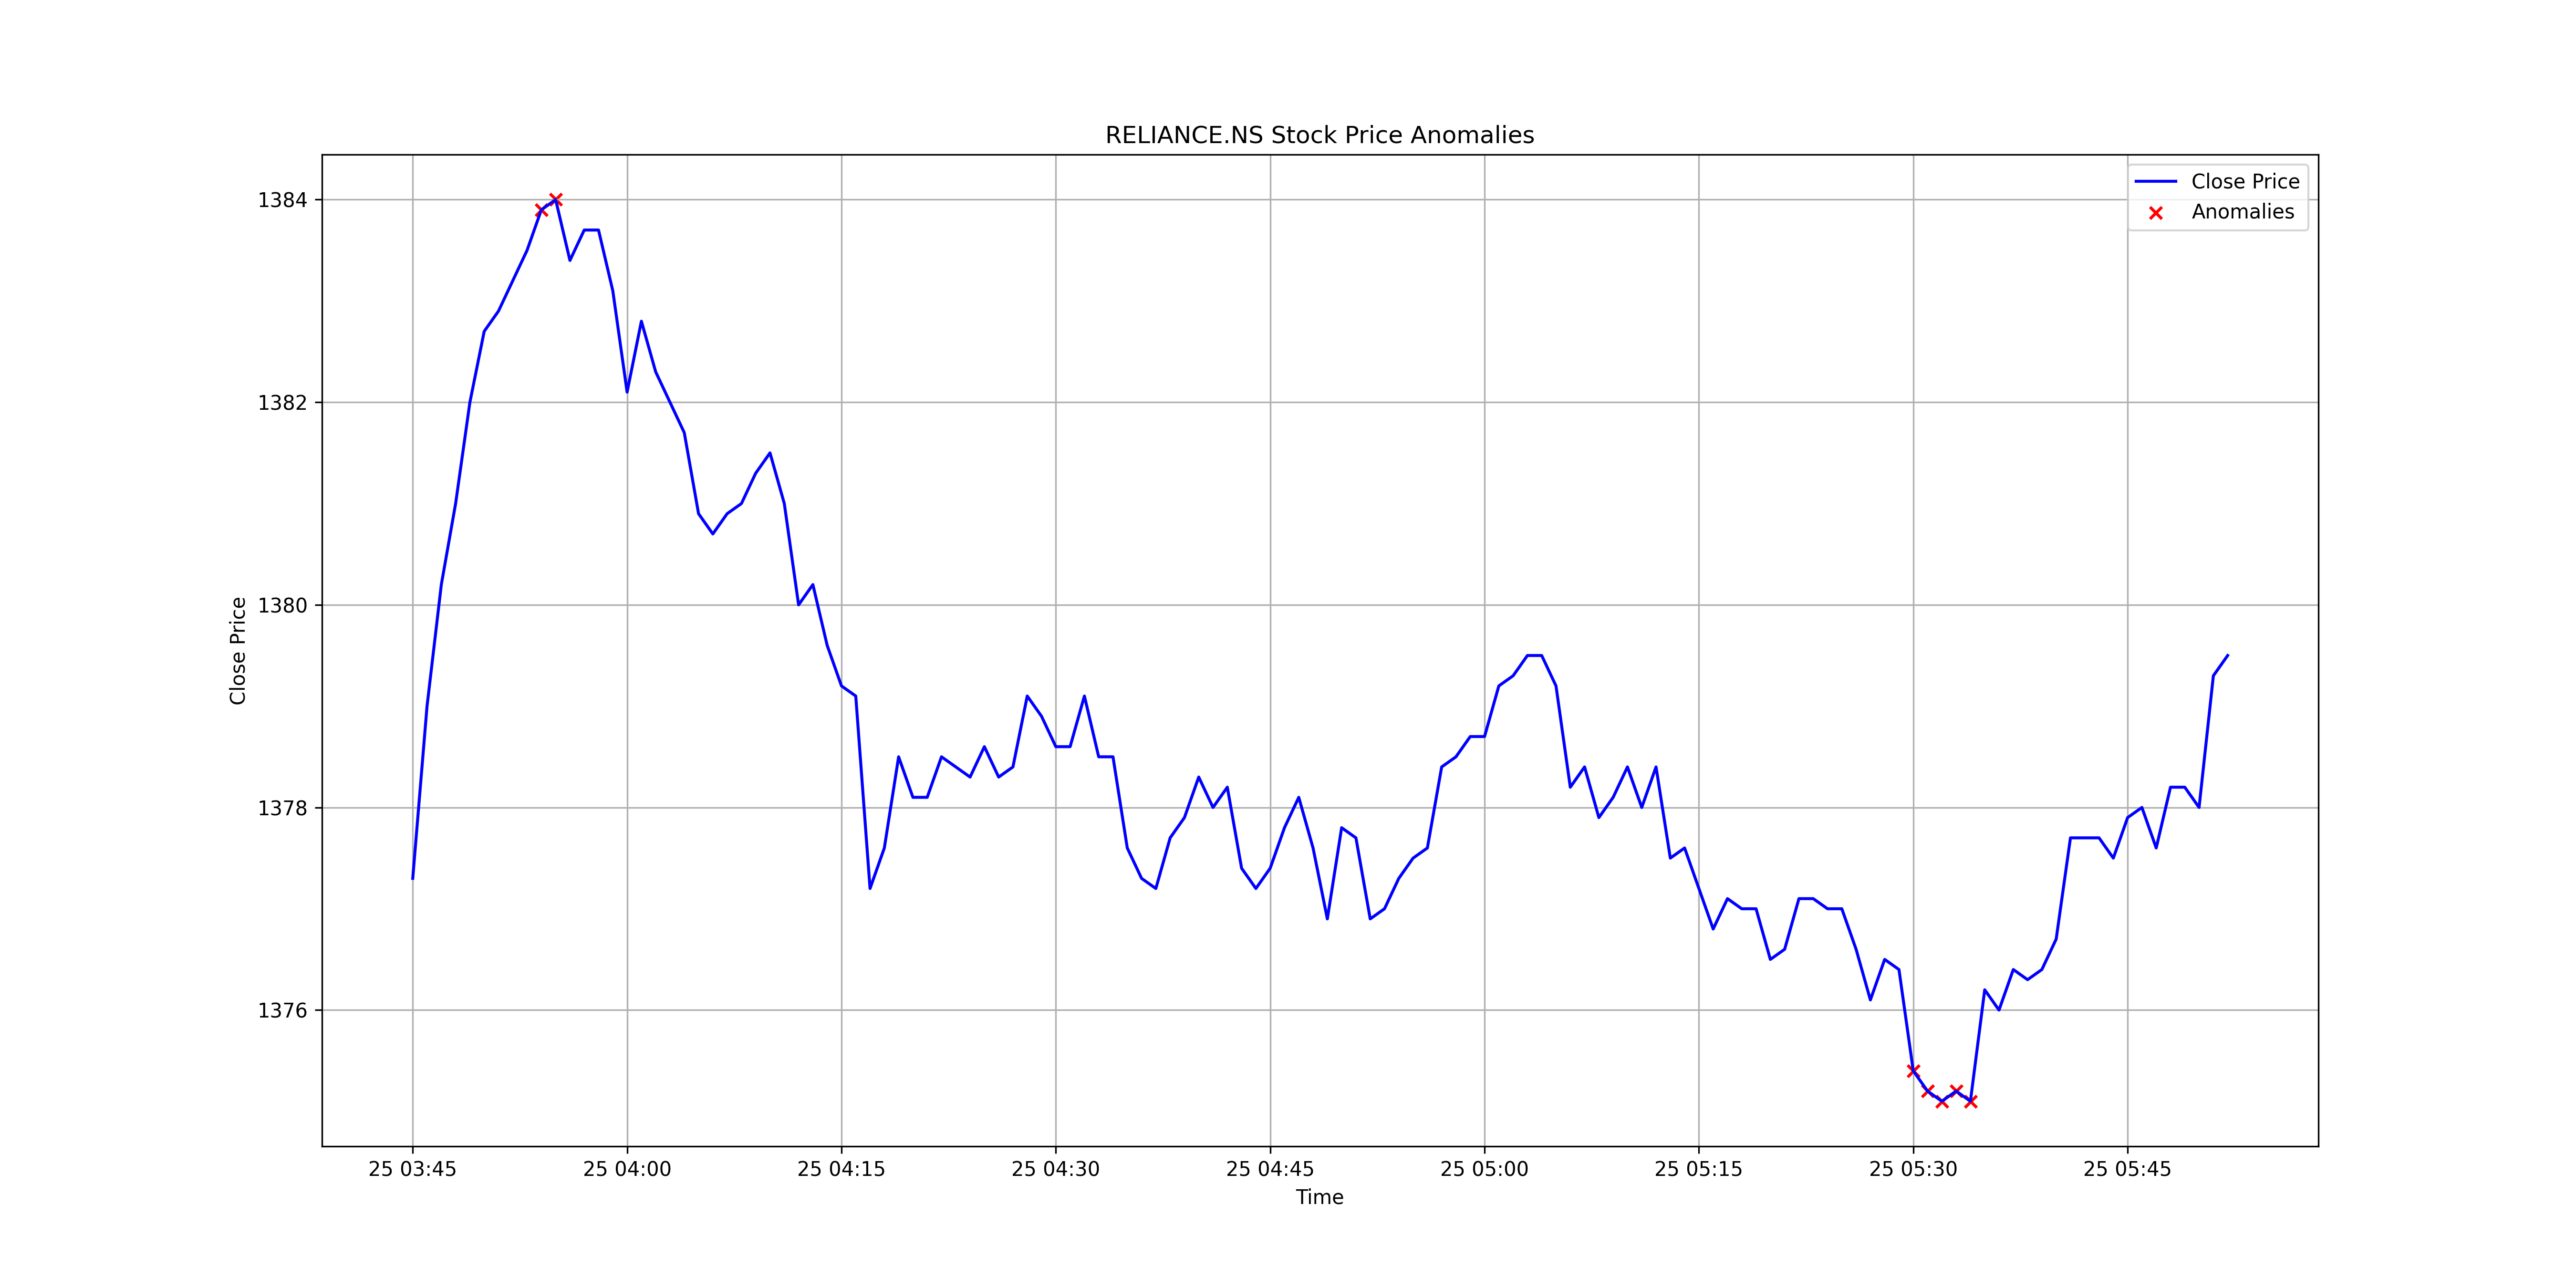

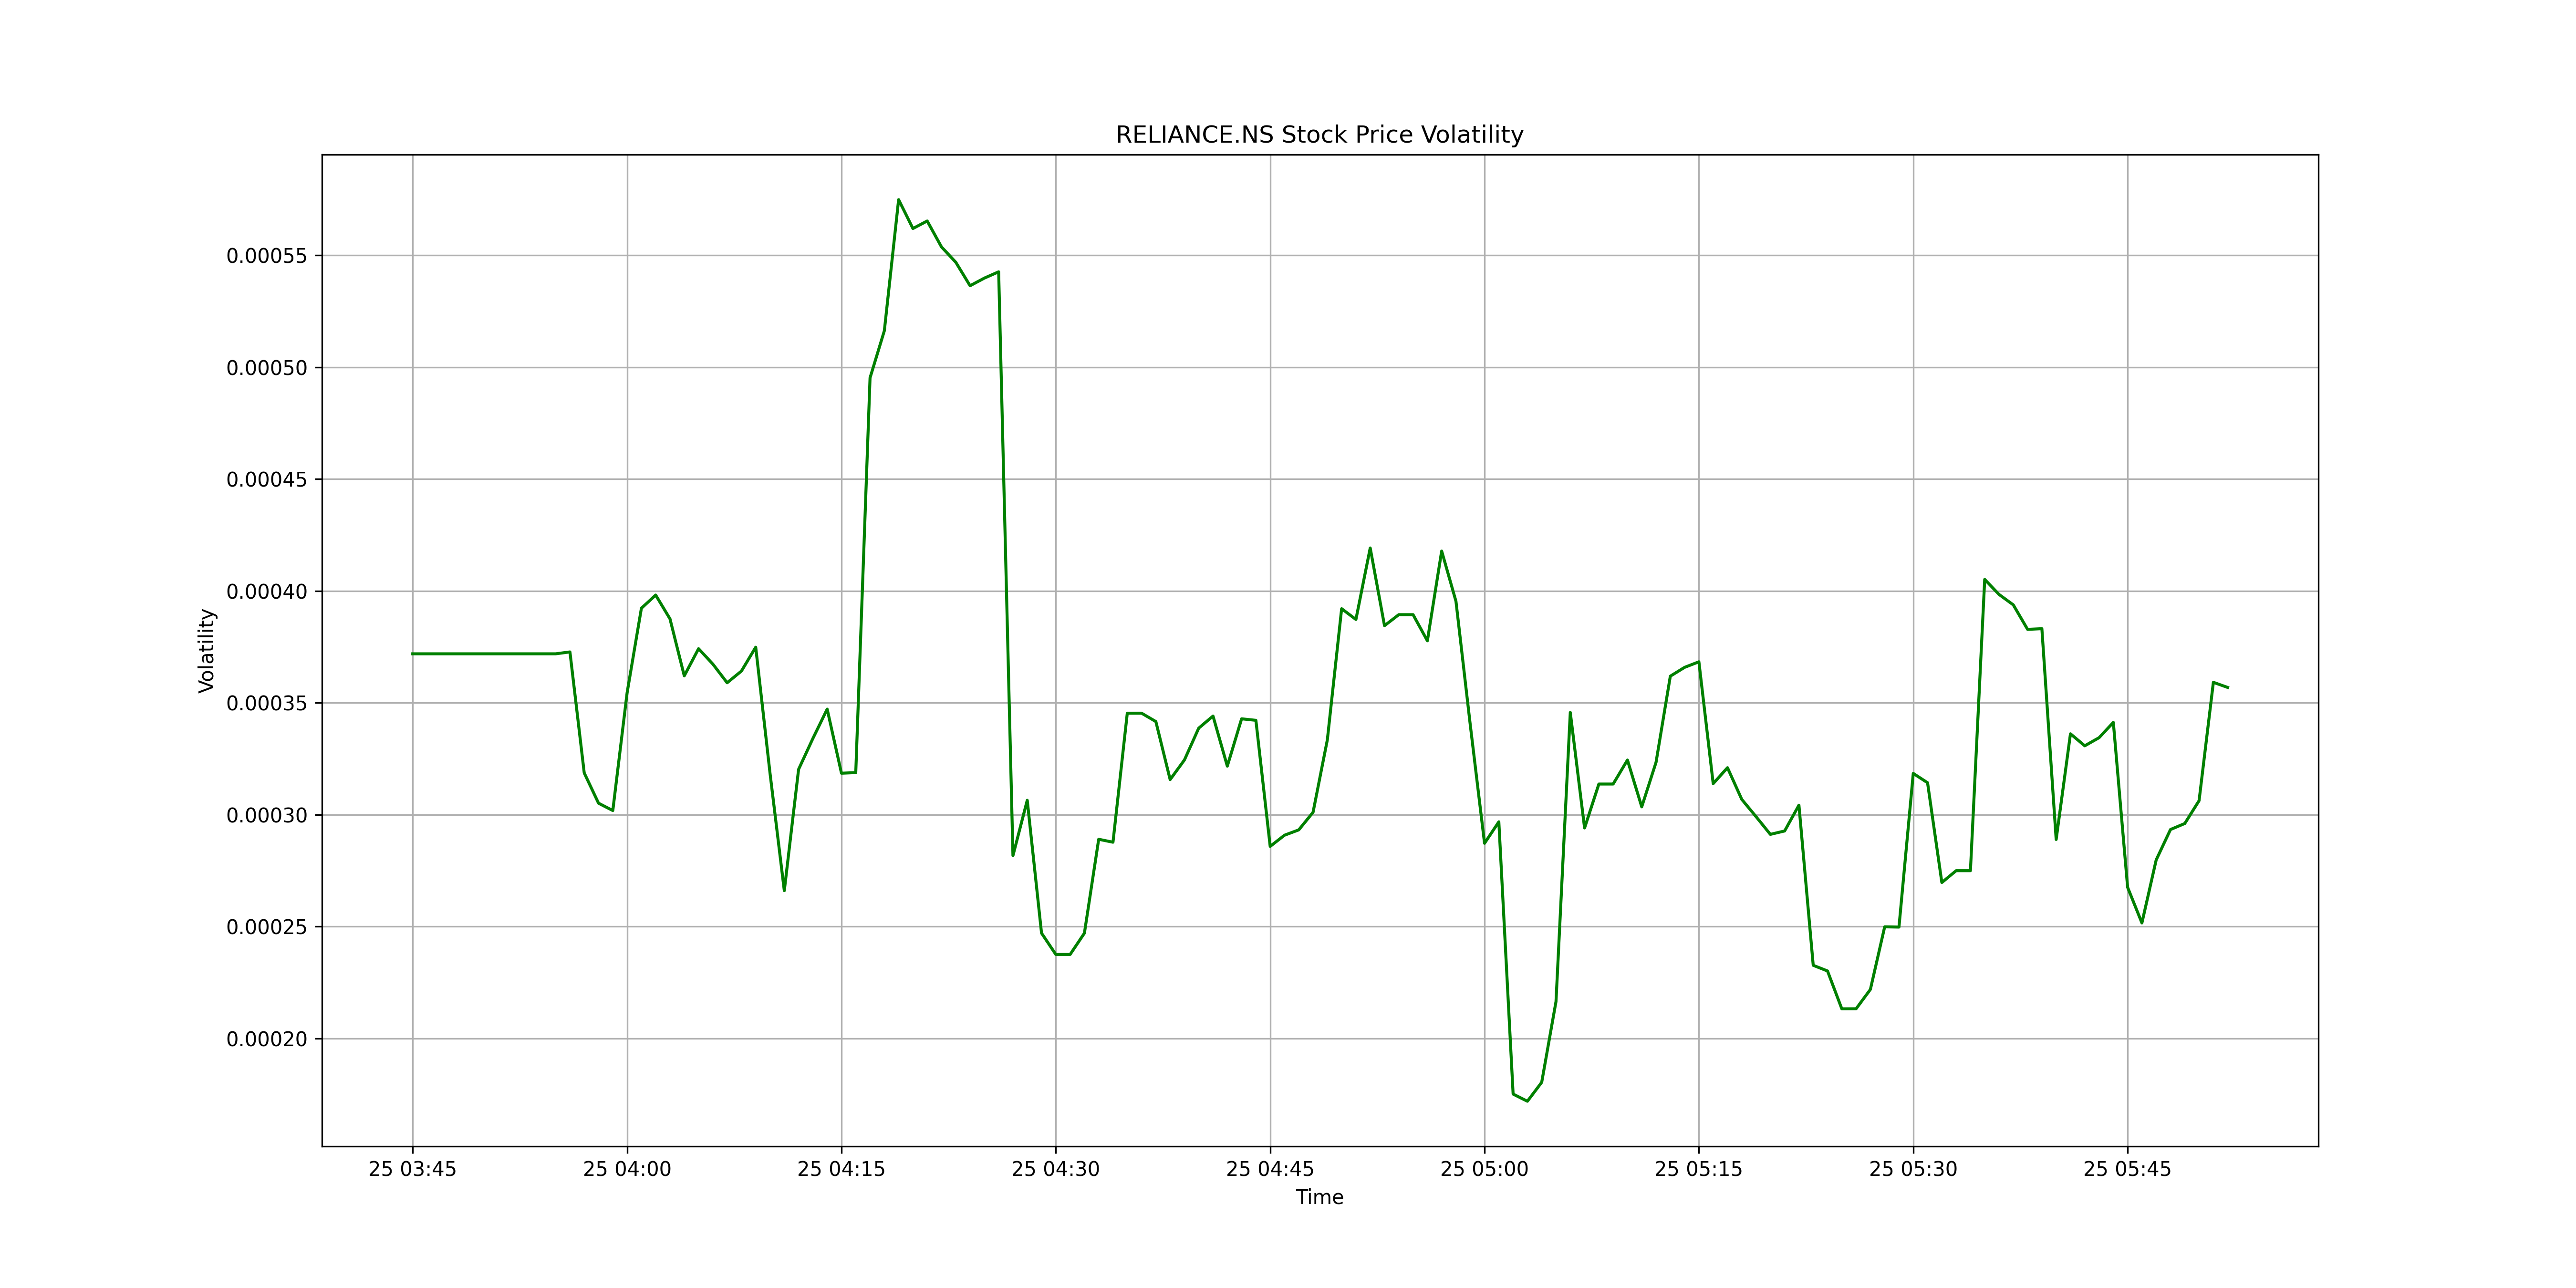

In [ ]:
from IPython.display import Image, display

# Display RELIANCE stock plots
display(Image(filename='stock_analysis/RELIANCE.NS_price_plot.png'))
display(Image(filename='stock_analysis/RELIANCE.NS_anomalies_plot.png'))
display(Image(filename='stock_analysis/RELIANCE.NS_volatility_plot.png'))
